# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "./src")


## 2. 데이터 로드

In [2]:
from data import load_mnist

(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test: (10000, 784) (10000,)


## 3. 구현 및 테스트 통과 확인

`src/` 아래 역할별 파일의 **TODO**를 순서대로 구현한 뒤 아래 셀을 실행하세요.
- 주요 구현 파일: `activations.py`, `layers.py`, `losses.py`, `optimizers.py`, `network.py`, `training.py`
- 구현 파일은 역할별 모듈을 직접 import합니다. 예: `from network import NeuralNetwork`
- 개발 순서: 과제 안내문 참조
- 테스트: `tests/` 아래의 단계별 단위 테스트를 필요한 파일부터 실행합니다. 처음에는 전체 테스트보다 맡은 부분의 테스트 파일을 먼저 실행하세요.
    - ReLU만 확인: `TEST_TARGET = "tests/test_relu.py"`
    - 파일 안의 일부 테스트만 확인: `PYTEST_KEYWORD = "backward"`
    - 전체 테스트 확인: `TEST_TARGET = "tests/"`

In [3]:
import subprocess
import sys
from pathlib import Path

# Colab/로컬 모두 현재 노트북 실행 위치를 저장소 루트로 사용합니다.
repo_dir = Path.cwd()

# 처음에는 자신이 구현 중인 부분의 테스트 파일만 실행하세요.
# 예: tests/test_relu.py, tests/test_affine.py, tests/test_training.py
TEST_TARGET = "tests/test_relu.py"

# 특정 이름이 들어간 테스트만 실행하고 싶을 때 사용합니다.
# 예: "backward". 전체 파일을 실행하려면 빈 문자열로 둡니다.
PYTEST_KEYWORD = ""

cmd = [sys.executable, "-m", "pytest", TEST_TARGET, "-v"]
if PYTEST_KEYWORD:
    cmd.extend(["-k", PYTEST_KEYWORD])

print("실행 경로:", repo_dir)
print("실행 명령:", " ".join(cmd))
result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(repo_dir)
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode == 0:
    print("\n선택한 테스트를 통과했습니다.")
else:
    print("\n선택한 테스트 중 실패가 있습니다.")


실행 경로: C:\Users\cedis\PyCharmMiscProject\mnist-lab
실행 명령: C:\Users\cedis\PyCharmMiscProject\mnist-lab\.venv\Scripts\python.exe -m pytest tests/test_relu.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PyCharmMiscProject\mnist-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PyCharmMiscProject\mnist-lab
collecting ... collected 3 items

tests/test_relu.py::TestReLU::test_relu_forward_positive PASSED          [ 33%]
tests/test_relu.py::TestReLU::test_relu_forward_negative_zero PASSED     [ 66%]
tests/test_relu.py::TestReLU::test_relu_backward PASSED                  [100%]

============================== 3 passed in 0.09s ==============================


선택한 테스트를 통과했습니다.


## 4. 모델·옵티마이저 생성 및 학습

In [4]:
import numpy as np
from network import NeuralNetwork
from optimizers import Adam
from losses import cross_entropy_loss
from training import evaluate

model = NeuralNetwork(
    use_batchnorm=True,
    use_dropout=True,
    dropout_ratio=0.1,
)
optimizer = Adam(lr=0.001)

epochs = 25
batch_size = 128
lr_decay = {
    16: 0.0005,
    22: 0.0002,
}

loss_history = []
acc_history = []

for epoch in range(1, epochs + 1):
    if epoch in lr_decay:
        optimizer.lr = lr_decay[epoch]

    indices = np.random.permutation(len(x_train))
    batch_losses = []

    for start in range(0, len(x_train), batch_size):
        batch_idx = indices[start:start + batch_size]
        x_batch = x_train[batch_idx]
        y_batch = y_train[batch_idx]

        y_pred = model.forward(x_batch, train=True)
        loss = cross_entropy_loss(y_pred, y_batch)
        batch_losses.append(loss)

        dout = y_pred.copy()
        dout[np.arange(y_batch.shape[0]), y_batch] -= 1
        dout /= y_batch.shape[0]

        model.backward(dout)
        optimizer.update(model.params, model.grads)

    epoch_loss = float(np.mean(batch_losses))
    test_acc, total_params = evaluate(model, x_test, y_test)

    loss_history.append(epoch_loss)
    acc_history.append(test_acc)

    print(
        f"epoch={epoch:02d} "
        f"loss={epoch_loss:.6f} "
        f"test_acc={test_acc:.2f}% "
        f"lr={optimizer.lr}"
    )


epoch=01 loss=0.210405 test_acc=97.05% lr=0.001
epoch=02 loss=0.086406 test_acc=97.48% lr=0.001
epoch=03 loss=0.058620 test_acc=98.01% lr=0.001
epoch=04 loss=0.045580 test_acc=97.90% lr=0.001
epoch=05 loss=0.034077 test_acc=98.08% lr=0.001
epoch=06 loss=0.029804 test_acc=98.11% lr=0.001
epoch=07 loss=0.023713 test_acc=98.05% lr=0.001
epoch=08 loss=0.021957 test_acc=98.22% lr=0.001
epoch=09 loss=0.019656 test_acc=98.16% lr=0.001
epoch=10 loss=0.018185 test_acc=98.17% lr=0.001
epoch=11 loss=0.016342 test_acc=98.19% lr=0.001
epoch=12 loss=0.014579 test_acc=98.20% lr=0.001
epoch=13 loss=0.013492 test_acc=98.27% lr=0.001
epoch=14 loss=0.012841 test_acc=98.22% lr=0.001
epoch=15 loss=0.010821 test_acc=98.31% lr=0.001
epoch=16 loss=0.006814 test_acc=98.54% lr=0.0005
epoch=17 loss=0.003988 test_acc=98.47% lr=0.0005
epoch=18 loss=0.003067 test_acc=98.41% lr=0.0005
epoch=19 loss=0.003029 test_acc=98.48% lr=0.0005
epoch=20 loss=0.003210 test_acc=98.44% lr=0.0005
epoch=21 loss=0.004150 test_acc=98.

## 5. 평가 및 손실 커브

Test Accuracy: 98.56%
Total Params: 537,354


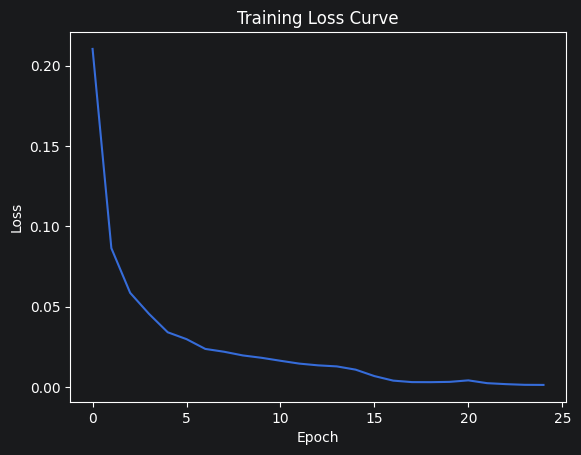

In [5]:
from training import evaluate, plot_loss_history

acc, n_params = evaluate(model, x_test, y_test)
print(f'Test Accuracy: {acc:.2f}%')
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)

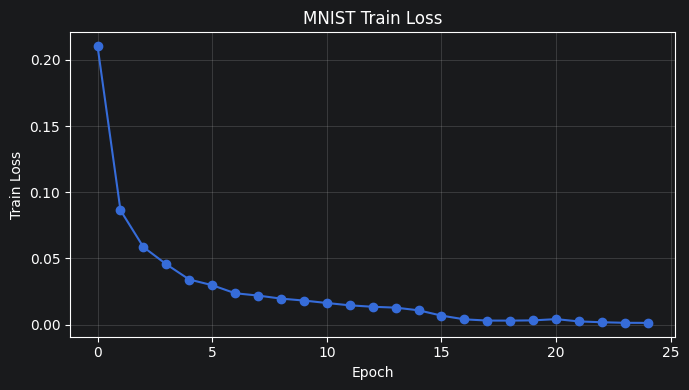

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("report_assets").mkdir(exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("MNIST Train Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("report_assets/mnist_base_loss_curve.png", dpi=170)
plt.show()

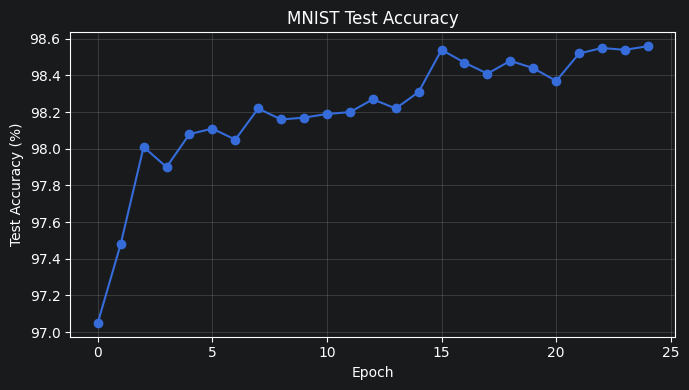

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("report_assets").mkdir(exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(acc_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("MNIST Test Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("report_assets/mnist_base_accuracy_curve.png", dpi=170)
plt.show()


In [8]:
from src.training import evaluate

test_acc, total_params = evaluate(model, x_test, y_test)

print(f"test accuracy: {test_acc:.2f}%")
print(f"total params: {total_params:,}")

test accuracy: 98.56%
total params: 537,354


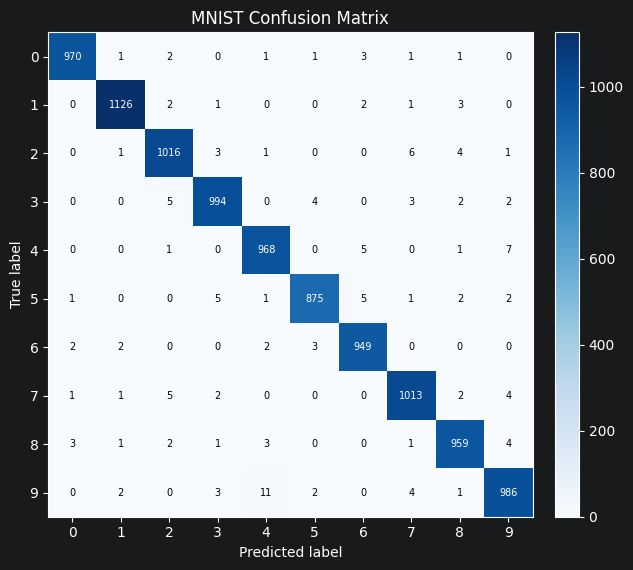

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("report_assets").mkdir(exist_ok=True)

y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

cm = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[int(true), int(pred)] += 1

plt.figure(figsize=(6.5, 5.8))
plt.imshow(cm, cmap="Blues")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("MNIST Confusion Matrix")
plt.xticks(range(10))
plt.yticks(range(10))

threshold = cm.max() * 0.55
for i in range(10):
    for j in range(10):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=7, color=color)

plt.tight_layout()
plt.savefig("report_assets/mnist_confusion_matrix.png", dpi=170)
plt.show()

In [10]:
import numpy as np

per_class = []
precisions = []
recalls = []
f1s = []

for cls in range(10):
    tp = cm[cls, cls]
    fp = cm[:, cls].sum() - tp
    fn = cm[cls, :].sum() - tp
    support = cm[cls, :].sum()

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

    per_class.append({
        "class": cls,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": int(support),
    })

print("macro precision:", np.mean(precisions))
print("macro recall:", np.mean(recalls))
print("macro f1:", np.mean(f1s))

for row in per_class:
    print(
        row["class"],
        f"precision={row['precision']*100:.2f}%",
        f"recall={row['recall']*100:.2f}%",
        f"f1={row['f1']*100:.2f}%",
        f"support={row['support']}",
    )

macro precision: 0.98555517295734
macro recall: 0.9855024758938766
macro f1: 0.9855250645491601
0 precision=99.28% recall=98.98% f1=99.13% support=980
1 precision=99.29% recall=99.21% f1=99.25% support=1135
2 precision=98.35% recall=98.45% f1=98.40% support=1032
3 precision=98.51% recall=98.42% f1=98.46% support=1010
4 precision=98.07% recall=98.57% f1=98.32% support=982
5 precision=98.87% recall=98.09% f1=98.48% support=892
6 precision=98.44% recall=99.06% f1=98.75% support=958
7 precision=98.35% recall=98.54% f1=98.45% support=1028
8 precision=98.36% recall=98.46% f1=98.41% support=974
9 precision=98.01% recall=97.72% f1=97.87% support=1009


In [11]:
from src.training import evaluate

test_acc, total_params = evaluate(model, x_test, y_test)

print(f"test accuracy: {test_acc:.2f}%")
print(f"total params: {total_params:,}")

test accuracy: 98.56%
total params: 537,354
